# CyberSentinel-EU Stage 2 COMPLETE (final)
**Fatema Husain Hasan (202508958) MSc AI Thesis**

Everything for Stage 2 in one notebook, in the right order:
data -> embeddings -> features -> classification -> grouped CV -> ablation
-> SHAP -> temporal holdout.

## 1. Setup

In [1]:
!pip install openai shap --quiet
import pandas as pd
import numpy as np
import json
import os
from openai import AzureOpenAI
print('ready')

ready


## 2. Azure credentials and connection

In [2]:
AZURE_ENDPOINT = "https://cybersentinel-resource.openai.azure.com/"
AZURE_KEY = "PASTE_YOUR_KEY"
EMBED_DEPLOYMENT = "text-embedding-3-small"
API_VERSION = "2024-10-21"

client = AzureOpenAI(azure_endpoint=AZURE_ENDPOINT, api_key=AZURE_KEY, api_version=API_VERSION)
print("connection OK, vector length:", len(client.embeddings.create(model=EMBED_DEPLOYMENT, input="test").data[0].embedding))

connection OK, vector length: 1536


## 3. Load data from GitHub

In [5]:
REPO = "https://raw.githubusercontent.com/Fatimaxx24/202508958_IT9099_Thesis/main/"
full = pd.read_csv(REPO + "labelling_master_1000_labelled.csv")
tracker = pd.read_csv(REPO + "gdpr_enforcement_tracker_full.csv", low_memory=False)

lab = full[full['manual_label'].isin(['cyber_malicious','cyber_nonmalicious','not_cyber'])].copy()
lab['is_cyber'] = lab['manual_label'].str.startswith('cyber').astype(int)
data = lab.merge(tracker[['ETid','Controller/Processor','Quoted Articles']],
                 on='ETid', how='left', suffixes=('','_t'))
print('labelled rows in use:', len(data))
print(data['manual_label'].value_counts().to_string())

labelled rows in use: 891
manual_label
cyber_nonmalicious    401
not_cyber             296
cyber_malicious       194


## 4. Embeddings (cached)

In [6]:
CACHE = "embeddings_cache_1000.json"
cache = json.load(open(CACHE)) if os.path.exists(CACHE) else {}

def embed(text):
    k = str(text)[:8000]
    if k in cache: return cache[k]
    v = client.embeddings.create(model=EMBED_DEPLOYMENT, input=k).data[0].embedding
    cache[k] = v
    return v

vecs=[]
for i, s in enumerate(data['Summary'].astype(str)):
    vecs.append(embed(s))
    if (i+1)%100==0:
        print(f'{i+1}/{len(data)} embedded'); json.dump(cache, open(CACHE,'w'))
json.dump(cache, open(CACHE,'w'))
emb = np.array(vecs)
print('embeddings shape:', emb.shape)

100/891 embedded
200/891 embedded
300/891 embedded
400/891 embedded
500/891 embedded
600/891 embedded
700/891 embedded
800/891 embedded
embeddings shape: (891, 1536)


## 5. Features: structured / embeddings / hybrid

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

data['year'] = pd.to_datetime(data['Date of Decision'], errors='coerce', format='mixed').dt.year
data['year'] = data['year'].fillna(data['year'].median())
data['log_fine'] = np.log1p(pd.to_numeric(data['Fine (EUR)'], errors='coerce')).fillna(-1)
data['n_articles'] = data['Quoted Articles'].astype(str).str.count('Art')

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat = ohe.fit_transform(data[['Country','Sector']].astype(str))
structured = np.hstack([cat, data[['year','log_fine','n_articles']].values])

pca = PCA(n_components=min(100, emb.shape[0]-1), random_state=42)
emb_pca = pca.fit_transform(emb)
hybrid = np.hstack([structured, emb_pca])
print(f'PCA {pca.n_components_} comps, variance {pca.explained_variance_ratio_.sum():.1%}')
print('structured:', structured.shape, '| emb:', emb_pca.shape, '| hybrid:', hybrid.shape)

PCA 100 comps, variance 77.2%
structured: (891, 44) | emb: (891, 100) | hybrid: (891, 144)


## 6. RESULT 1 - Cyber vs Non-cyber

In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, GroupKFold
from sklearn.ensemble import RandomForestClassifier

y = data['is_cyber'].values
cv = StratifiedKFold(5, shuffle=True, random_state=42)
print("-CYBER vs NON-CYBER-")
for name, X in [('Structured', structured), ('Embeddings', emb_pca), ('Hybrid', hybrid)]:
    f1 = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=42), X, y, cv=cv, scoring='f1_macro')
    print(f'{name:12s} macro-F1 = {f1.mean():.3f} ± {f1.std():.3f}')

-CYBER vs NON-CYBER-
Structured   macro-F1 = 0.736 ± 0.038
Embeddings   macro-F1 = 0.793 ± 0.029
Hybrid       macro-F1 = 0.808 ± 0.022


## 7. RESULT 2 - Malicious vs Non-malicious

In [9]:
cyber_mask = data['manual_label'].isin(['cyber_malicious','cyber_nonmalicious']).values
ym = (data.loc[cyber_mask,'manual_label']=='cyber_malicious').astype(int).values
print(f'cyber records: {cyber_mask.sum()} | malicious: {ym.sum()} | non-malicious: {cyber_mask.sum()-ym.sum()}')
print("\n- MALICIOUS vs NON-MALICIOUS -")
for name, X in [('Structured', structured[cyber_mask]), ('Hybrid', hybrid[cyber_mask])]:
    f1 = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=42), X, ym,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='f1_macro')
    print(f'{name:12s} macro-F1 = {f1.mean():.3f} ± {f1.std():.3f}')

cyber records: 595 | malicious: 194 | non-malicious: 401

- MALICIOUS vs NON-MALICIOUS -
Structured   macro-F1 = 0.699 ± 0.031
Hybrid       macro-F1 = 0.713 ± 0.049


## 8. RESULT 3 - Grouped CV + leakage ablation

In [10]:
groups = data['Controller/Processor'].astype(str).values
gkf = GroupKFold(n_splits=5)
def grouped_f1(X):
    return cross_val_score(RandomForestClassifier(n_estimators=300, random_state=42),
                           X, y, cv=gkf, groups=groups, scoring='f1_macro').mean()

struct_noreg = np.hstack([cat, data[['year']].values])
hybrid_noreg = np.hstack([struct_noreg, emb_pca])

print("- GROUPED CV (by organisation) -")
print(f'Hybrid grouped macro-F1      = {grouped_f1(hybrid):.3f}')
print("\n- LEAKAGE ABLATION -")
print(f'Hybrid (all features)        = {grouped_f1(hybrid):.3f}')
print(f'Hybrid (no fine/articles)    = {grouped_f1(hybrid_noreg):.3f}')
print("Small drop => model does NOT rely on post-incident regulatory features.")

- GROUPED CV (by organisation) -
Hybrid grouped macro-F1      = 0.784

- LEAKAGE ABLATION -
Hybrid (all features)        = 0.784
Hybrid (no fine/articles)    = 0.776
Small drop => model does NOT rely on post-incident regulatory features.


## 9. RESULT 4 - SHAP explanations (screenshot the plot)

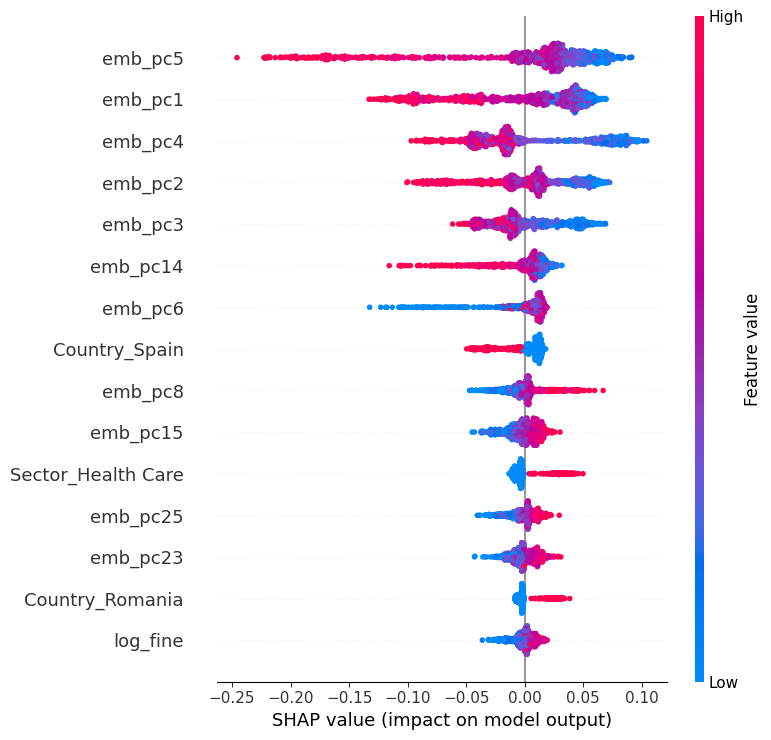

In [11]:
import shap
cat_names = list(ohe.get_feature_names_out(['Country','Sector']))
feat_names = cat_names + ['year','log_fine','n_articles'] + [f'emb_pc{i+1}' for i in range(emb_pca.shape[1])]

model = RandomForestClassifier(n_estimators=300, random_state=42).fit(hybrid, y)
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(hybrid)
vals = sv[1] if isinstance(sv, list) else (sv[:,:,1] if sv.ndim==3 else sv)

shap.summary_plot(vals, hybrid, feature_names=feat_names, max_display=15, show=True)

In [12]:
imp = pd.DataFrame({'feature': feat_names, 'mean_abs_shap': np.abs(vals).mean(axis=0)})
print(imp.sort_values('mean_abs_shap', ascending=False).head(15).to_string(index=False))

           feature  mean_abs_shap
           emb_pc5       0.052702
           emb_pc1       0.045485
           emb_pc4       0.041613
           emb_pc2       0.030383
           emb_pc3       0.023449
          emb_pc14       0.015844
           emb_pc6       0.015374
     Country_Spain       0.012443
           emb_pc8       0.010497
          emb_pc15       0.009312
Sector_Health Care       0.009095
          emb_pc25       0.008083
          emb_pc23       0.008063
   Country_Romania       0.006396
          log_fine       0.006283


## 10. RESULT 5 - Temporal holdout (train 2018-2022, test 2023+)

In [13]:
from sklearn.metrics import f1_score, classification_report
train_mask = (data['year'] <= 2022).values
test_mask  = (data['year'] >= 2023).values
print(f'train: {train_mask.sum()} | test: {test_mask.sum()}')

m = RandomForestClassifier(n_estimators=300, random_state=42).fit(hybrid[train_mask], y[train_mask])
pred = m.predict(hybrid[test_mask])
print(f'\nTemporal holdout macro-F1 = {f1_score(y[test_mask], pred, average="macro"):.3f}')
print(classification_report(y[test_mask], pred, target_names=['non-cyber','cyber']))

train: 515 | test: 376

Temporal holdout macro-F1 = 0.727
              precision    recall  f1-score   support

   non-cyber       0.88      0.45      0.59       127
       cyber       0.77      0.97      0.86       249

    accuracy                           0.79       376
   macro avg       0.83      0.71      0.73       376
weighted avg       0.81      0.79      0.77       376



## 11. Chapter 5 Table

In [15]:
# TABLE 5.1 full metrics for Chapter 5
from sklearn.model_selection import cross_validate

rows = []
for name, X in [('Baseline 1 - Structured only', structured),
                ('Baseline 2 - Embeddings only', emb_pca),
                ('Proposed - Hybrid', hybrid)]:
    sc = cross_validate(RandomForestClassifier(n_estimators=300, random_state=42),
                        X, y, cv=cv, scoring=['f1_macro','accuracy','roc_auc'])
    rows.append({'Model': name,
                 'Macro-F1': round(sc['test_f1_macro'].mean(),3),
                 'Accuracy': round(sc['test_accuracy'].mean(),3),
                 'AUC':      round(sc['test_roc_auc'].mean(),3),
                 'F1 std':   round(sc['test_f1_macro'].std(),3)})

# ablation row (grouped CV, regulatory features removed)
sc = cross_validate(RandomForestClassifier(n_estimators=300, random_state=42),
                    hybrid_noreg, y, cv=gkf, groups=groups,
                    scoring=['f1_macro','accuracy','roc_auc'])
rows.append({'Model': 'Proposed + ablation (no fine/articles)',
             'Macro-F1': round(sc['test_f1_macro'].mean(),3),
             'Accuracy': round(sc['test_accuracy'].mean(),3),
             'AUC':      round(sc['test_roc_auc'].mean(),3),
             'F1 std':   round(sc['test_f1_macro'].std(),3)})

pd.DataFrame(rows)

,Model,Macro-F1,Accuracy,AUC,F1 std
0,Baseline 1 - Structured only,0.736,0.777,0.826,0.038
1,Baseline 2 - Embeddings only,0.793,0.837,0.934,0.029
2,Proposed - Hybrid,0.808,0.847,0.932,0.022
3,Proposed + ablation (no fine/articles),0.776,0.826,0.928,0.017


## 12. Five-configuration leakage ablation

In [16]:
# Five-configuration leakage ablation, all under grouped CV
country_idx = [i for i, n in enumerate(ohe.get_feature_names_out(['Country','Sector']))
               if n.startswith('Country_')]
keep = [i for i in range(cat.shape[1]) if i not in country_idx]
struct_nocountry = np.hstack([cat[:, keep], data[['year','log_fine','n_articles']].values])
hybrid_nocountry = np.hstack([struct_nocountry, emb_pca])

print("-FIVE-CONFIGURATION ABLATION (grouped CV)-")
for name, X in [('1. Structured only',           structured),
                ('2. Embeddings only',           emb_pca),
                ('3. Hybrid (full)',             hybrid),
                ('4. Hybrid - country',          hybrid_nocountry),
                ('5. Hybrid - fine & articles',  hybrid_noreg)]:
    f1 = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=42),
                         X, y, cv=gkf, groups=groups, scoring='f1_macro')
    print(f'{name:30s} macro-F1 = {f1.mean():.3f}')

-FIVE-CONFIGURATION ABLATION (grouped CV)-
1. Structured only             macro-F1 = 0.715
2. Embeddings only             macro-F1 = 0.787
3. Hybrid (full)               macro-F1 = 0.784
4. Hybrid - country            macro-F1 = 0.791
5. Hybrid - fine & articles    macro-F1 = 0.776


## 13. Ablation across five seeds

In [17]:
# Ablation stability across seeds
deltas = []
for seed in [1, 7, 21, 42, 99]:
    full  = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=seed),
                            hybrid, y, cv=gkf, groups=groups, scoring='f1_macro').mean()
    noreg = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=seed),
                            hybrid_noreg, y, cv=gkf, groups=groups, scoring='f1_macro').mean()
    deltas.append(full - noreg)
    print(f'seed {seed:3d}: full {full:.3f} | no-reg {noreg:.3f} | delta {full-noreg:+.3f}')
print(f'\nmean delta = {np.mean(deltas):.3f} ± {np.std(deltas):.3f}')

seed   1: full 0.785 | no-reg 0.774 | delta +0.011
seed   7: full 0.784 | no-reg 0.790 | delta -0.006
seed  21: full 0.778 | no-reg 0.784 | delta -0.005
seed  42: full 0.784 | no-reg 0.776 | delta +0.008
seed  99: full 0.795 | no-reg 0.781 | delta +0.014

mean delta = 0.004 ± 0.008


## 14. Wilcoxon test (delivers H1's promised statistics)

In [18]:
from scipy.stats import wilcoxon
SEEDS = [1, 7, 21, 42, 99]
s_all, h_all = [], []
for seed in SEEDS:
    cvs = StratifiedKFold(5, shuffle=True, random_state=seed)
    s_all.extend(cross_val_score(RandomForestClassifier(n_estimators=300, random_state=seed),
                                 structured, y, cv=cvs, scoring='f1_macro'))
    h_all.extend(cross_val_score(RandomForestClassifier(n_estimators=300, random_state=seed),
                                 hybrid, y, cv=cvs, scoring='f1_macro'))
s_all, h_all = np.array(s_all), np.array(h_all)
stat, p = wilcoxon(h_all, s_all)
n = len(s_all)
r_rb = 1 - (2*stat)/(n*(n+1)/2)
print(f"n paired folds = {n}")
print(f"structured mean = {s_all.mean():.3f} | hybrid mean = {h_all.mean():.3f}")
print(f"mean difference = {(h_all-s_all).mean():.3f}")
print(f"W = {stat:.1f} | p = {p:.5f} | effect size r_rb = {r_rb:.3f}")

n paired folds = 25
structured mean = 0.736 | hybrid mean = 0.808
mean difference = 0.072
W = 2.0 | p = 0.00000 | effect size r_rb = 0.988


## checklist
- Screenshot results from cells 6, 7, 8, 9 (plot), 10
- Note the commit hash for Chapter 5